# Weather Prediction Using Time-Series Neural Networks
### Multi-Step Forecasting with LSTM / GRU

**Dataset:** Weather in Szeged 2006–2016 (Kaggle) — `weatherHistory.csv`




## 1. Setup

> **Note on target column:** the raw dataset does not include a `Date` /
> `Time` split — the timestamp lives in `Formatted Date`, and the
> measurements are hourly. Set `DATA_PATH` below to wherever you upload
> `weatherHistory.csv`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

DATA_PATH = "/kaggle/input/datasets/muthuj7/weather-dataset/weatherHistory.csv"   # <-- change this to your uploaded file's path

# Config
LOOKBACK   = 72   # use the last 72 hourly readings (3 days) as input context
HORIZON    = 24   # forecast the next 24 hourly readings (multi-step target)
BATCH_SIZE = 64
EPOCHS     = 40
MODEL_TYPE = "LSTM"   # "LSTM" or "GRU" -- swap easily to compare both


## 2. Load Data & Handle Missing Values

`Precip Type` is the only column with real gaps in this dataset (a handful
of rows have neither "rain" nor "snow" recorded). `Loud Cover` is constant
(always 0) across the whole dataset, so it carries no information and is
dropped.

`Pressure (millibars)` also has a known sensor-error issue: a number of
rows record exactly `0`, which is not a physically real atmospheric
pressure reading (sea-level pressure is normally ~950–1050 mb). These are
treated as missing values and interpolated, the same way as any other gap
— not dropped outright, so the hourly timeline stays continuous for the
sliding-window sequences.


In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(96453, 12)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [3]:
# Parse the timestamp. The format includes a UTC offset, e.g. "2006-04-01 00:00:00.000 +0200"
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], utc=True)
df = df.sort_values("Formatted Date").reset_index(drop=True)

print("Missing values per column:")
print(df.isna().sum())

print("\nUnique Precip Type values:", df["Precip Type"].unique())

n_zero_pressure = (df["Pressure (millibars)"] == 0).sum()
print(f"\nRows with Pressure (millibars) == 0 (sensor error): {n_zero_pressure} "
      f"({n_zero_pressure / len(df) * 100:.2f}% of rows)")


Missing values per column:
Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

Unique Precip Type values: ['rain' 'snow' nan]

Rows with Pressure (millibars) == 0 (sensor error): 1288 (1.34% of rows)


In [4]:
# --- Handle missing values ---
# Precip Type: fill with the most frequent category, then encode
df["Precip Type"] = df["Precip Type"].fillna(df["Precip Type"].mode()[0])

# Loud Cover is constant (always 0) -> drop, it adds no signal
if df["Loud Cover"].nunique() <= 1:
    df = df.drop(columns=["Loud Cover"])

# Drop free-text columns not used as numeric model features
# (Summary / Daily Summary are categorical text descriptions; Summary's
#  information is already captured numerically by the weather variables)
text_cols = ["Summary", "Daily Summary"]
df = df.drop(columns=[c for c in text_cols if c in df.columns])

# Encode Precip Type (rain/snow) as a numeric feature
le = LabelEncoder()
df["Precip Type"] = le.fit_transform(df["Precip Type"])
print("Precip Type classes:", dict(zip(le.classes_, le.transform(le.classes_))))

# Pressure == 0 is a sensor error, not a real reading -> treat as missing
df.loc[df["Pressure (millibars)"] == 0, "Pressure (millibars)"] = np.nan

# Any remaining nulls in numeric columns (including the pressure fix above)
# -> interpolate (time-series aware), keeping the hourly timeline continuous
df = df.set_index("Formatted Date")
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].interpolate(method="time").ffill().bfill()

assert df.isna().sum().sum() == 0, "Still have missing values!"
print(f"Pressure (millibars) range after cleaning: "
      f"{df['Pressure (millibars)'].min():.1f} - {df['Pressure (millibars)'].max():.1f}")
df.head()


Precip Type classes: {'rain': np.int64(0), 'snow': np.int64(1)}
Pressure (millibars) range after cleaning: 973.8 - 1046.4


,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
Formatted Date,,,,,,,,
2005-12-31 23:00:00+00:00,0,0.577778,-4.050000,0.89,17.1143,140.0,9.9820,1016.66
2006-01-01 00:00:00+00:00,0,1.161111,-3.238889,0.85,16.6152,139.0,9.9015,1016.15
2006-01-01 01:00:00+00:00,0,1.666667,-3.155556,0.82,20.2538,140.0,9.9015,1015.87
2006-01-01 02:00:00+00:00,0,1.711111,-2.194444,0.82,14.4900,140.0,9.9015,1015.56
2006-01-01 03:00:00+00:00,0,1.183333,-2.744444,0.86,13.9426,134.0,9.9015,1014.98


## 3. Feature Engineering

We add cyclical (sine/cosine) encodings of hour-of-day and day-of-year so
the network can learn seasonal / daily periodicity without treating time
as a raw, discontinuous integer.


In [5]:
df["hour"] = df.index.hour
df["day_of_year"] = df.index.dayofyear

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["doy_sin"]  = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
df["doy_cos"]  = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

df = df.drop(columns=["hour", "day_of_year"])

FEATURE_COLS = [
    "Temperature (C)", "Apparent Temperature (C)", "Humidity",
    "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)",
    "Pressure (millibars)", "Precip Type",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos",
]

# We forecast these variables (multi-target, multi-step)
TARGET_COLS = ["Temperature (C)", "Humidity", "Pressure (millibars)"]

df = df[FEATURE_COLS]
df.describe()


,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Precip Type,hour_sin,hour_cos,doy_sin,doy_cos
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,9.645300e+04,9.645300e+04,96453.000000,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,1016.818534,0.111059,7.867242e-06,-2.936095e-05,-0.000116,-0.000121
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,7.779138,0.314207,7.071191e-01,7.071018e-01,0.707057,0.707164
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,973.780000,0.000000,-1.000000e+00,-1.000000e+00,-0.999999,-0.999979
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,1012.120000,0.000000,-7.071068e-01,-7.071068e-01,-0.703677,-0.707487
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,1016.560000,0.000000,1.224647e-16,-1.836970e-16,-0.004301,0.001075
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,1021.170000,0.000000,7.071068e-01,7.071068e-01,0.706727,0.702913
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,1046.380000,1.000000,1.000000e+00,1.000000e+00,0.999986,0.999991


## 4. Train / Val / Test Split (chronological) + Scaling

Time-series data must be split **chronologically** (never shuffled before
splitting) to avoid leaking future information into training.


In [6]:
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

# Fit scaler ONLY on training data to prevent leakage
feature_scaler = MinMaxScaler()
train_scaled = feature_scaler.fit_transform(train_df)
val_scaled   = feature_scaler.transform(val_df)
test_scaled  = feature_scaler.transform(test_df)

train_scaled = pd.DataFrame(train_scaled, columns=df.columns, index=train_df.index)
val_scaled   = pd.DataFrame(val_scaled,   columns=df.columns, index=val_df.index)
test_scaled  = pd.DataFrame(test_scaled,  columns=df.columns, index=test_df.index)

target_idx = [df.columns.get_loc(c) for c in TARGET_COLS]
print("Target column indices:", dict(zip(TARGET_COLS, target_idx)))


Train: 67517  Val: 14468  Test: 14468
Target column indices: {'Temperature (C)': 0, 'Humidity': 2, 'Pressure (millibars)': 6}


## 5. Build Sliding-Window Sequences for Multi-Step Forecasting

Each sample:
- **X**: `LOOKBACK` past hourly readings of all features → shape `(LOOKBACK, n_features)`
- **y**: the next `HORIZON` hourly readings of the target variables only → shape `(HORIZON, n_targets)`

This is a direct multi-step ("sequence-to-sequence") formulation: the model
outputs the whole future horizon in one forward pass, which avoids the
error accumulation that plagues recursive one-step-at-a-time forecasting.


In [7]:
def make_sequences(data: pd.DataFrame, lookback: int, horizon: int, target_idx: list[int]):
    values = data.values
    X, y = [], []
    for i in range(len(values) - lookback - horizon + 1):
        X.append(values[i : i + lookback])
        y.append(values[i + lookback : i + lookback + horizon, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_sequences(train_scaled, LOOKBACK, HORIZON, target_idx)
X_val,   y_val   = make_sequences(val_scaled,   LOOKBACK, HORIZON, target_idx)
X_test,  y_test  = make_sequences(test_scaled,  LOOKBACK, HORIZON, target_idx)

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   " y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, " y_test: ", y_test.shape)


X_train: (67422, 72, 12)  y_train: (67422, 24, 3)
X_val:   (14373, 72, 12)  y_val:   (14373, 24, 3)
X_test:  (14373, 72, 12)  y_test:  (14373, 24, 3)


## 6. Model: LSTM/GRU Encoder → Dense Multi-Step Decoder

The recurrent layer encodes the `LOOKBACK`-length history into a context
vector; a Dense "decoder" head then projects that context to
`HORIZON x n_targets` predictions in one shot (a common, effective
approach for direct multi-step forecasting).


In [8]:
def build_model(n_features: int, n_targets: int, lookback: int, horizon: int,
                 rnn_type: str = "LSTM", units: int = 128) -> keras.Model:
    RNNLayer = layers.LSTM if rnn_type.upper() == "LSTM" else layers.GRU

    inputs = keras.Input(shape=(lookback, n_features))
    x = RNNLayer(units, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = RNNLayer(units // 2, return_sequences=False)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(horizon * n_targets)(x)
    outputs = layers.Reshape((horizon, n_targets))(x)

    model = keras.Model(inputs, outputs, name=f"{rnn_type}_multistep_forecaster")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model

n_features = X_train.shape[-1]
n_targets  = len(TARGET_COLS)

model = build_model(n_features, n_targets, LOOKBACK, HORIZON, rnn_type=MODEL_TYPE)
model.summary()


I0000 00:00:1785711446.655901      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785711446.659218      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "LSTM_multistep_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 72, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 72, 128)        │        72,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 72)             │         4,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 24, 3)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,280 (493.28 KB)

 Trainable params: 126,280 (493.28 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/40
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 0.0186 - mae: 0.0980 - val_loss: 0.0055 - val_mae: 0.0530 - learning_rate: 0.0010
Epoch 2/40
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0081 - mae: 0.0671 - val_loss: 0.0049 - val_mae: 0.0491 - learning_rate: 0.0010
Epoch 3/40
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0067 - mae: 0.0601 - val_loss: 0.0047 - val_mae: 0.0480 - learning_rate: 0.0010
Epoch 4/40
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0060 - mae: 0.0559 - val_loss: 0.0045 - val_mae: 0.0465 - learning_rate: 0.0010
Epoch 5/40
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0055 - mae: 0.0527 - val_loss: 0.0043 - val_mae: 0.0449 - learning_rate: 0.0010
Epoch 6/40
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0051 - mae: 0.0508 - val_loss: 0.0043 - val_mae: 0.0449 - learning_rate: 0.0010
Epoch 7/40
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0049 - mae: 0.0495 - val_loss: 0.0042 - val_mae: 0.0445 - 

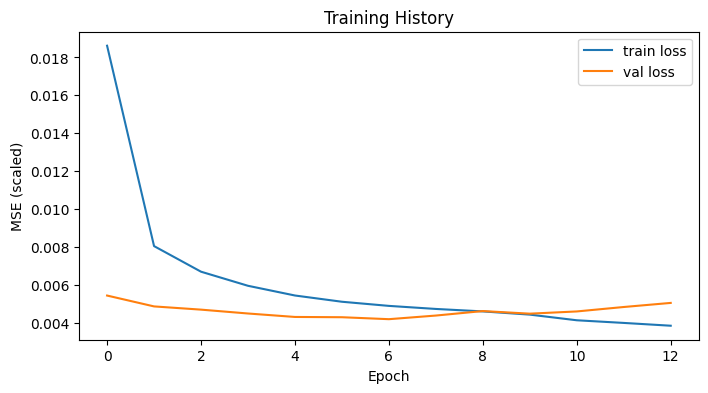

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("MSE (scaled)"); plt.legend(); plt.title("Training History")
plt.show()


## 8. Evaluate: Per-Horizon-Step Metrics

Rather than a single overall score, we report MAE/RMSE **per forecast
step** (step 1 = next hour ... step 24 = 24 hours ahead) to see how
accuracy degrades further into the future, and we inverse-transform back
to real units (°C, %, millibars) for interpretability.


In [11]:
def inverse_transform_targets(y_scaled: np.ndarray) -> np.ndarray:
    """Inverse-scale an array shaped (n_samples, horizon, n_targets) back to real units."""
    n_samples, horizon, n_targets = y_scaled.shape
    flat = y_scaled.reshape(-1, n_targets)
    dummy = np.zeros((flat.shape[0], len(FEATURE_COLS)))
    for j, col in enumerate(TARGET_COLS):
        dummy[:, df.columns.get_loc(col)] = flat[:, j]
    inv = feature_scaler.inverse_transform(dummy)
    result = np.stack([inv[:, df.columns.get_loc(c)] for c in TARGET_COLS], axis=1)
    return result.reshape(n_samples, horizon, n_targets)

y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = inverse_transform_targets(y_pred_scaled)
y_true = inverse_transform_targets(y_test)

per_step_mae  = np.mean(np.abs(y_true - y_pred), axis=(0, 2))
per_step_rmse = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=(0, 2)))

for target_i, col in enumerate(TARGET_COLS):
    mae  = mean_absolute_error(y_true[:, :, target_i].ravel(), y_pred[:, :, target_i].ravel())
    rmse = np.sqrt(mean_squared_error(y_true[:, :, target_i].ravel(), y_pred[:, :, target_i].ravel()))
    print(f"{col:>22s}  |  overall MAE = {mae:6.3f}   overall RMSE = {rmse:6.3f}")


       Temperature (C)  |  overall MAE =  1.840   overall RMSE =  2.422
              Humidity  |  overall MAE =  0.071   overall RMSE =  0.097
  Pressure (millibars)  |  overall MAE =  1.829   overall RMSE =  2.608


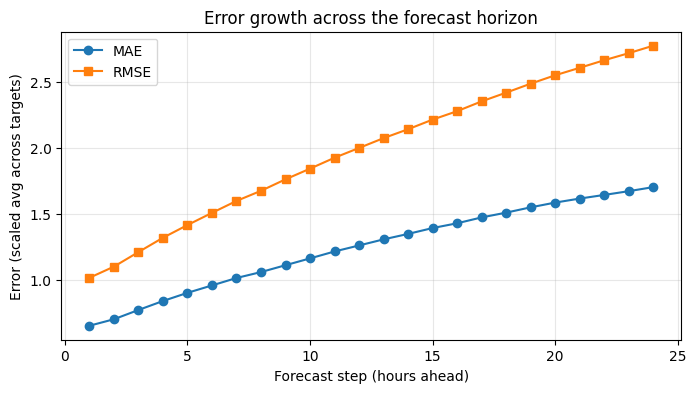

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, HORIZON + 1), per_step_mae, marker="o", label="MAE")
plt.plot(range(1, HORIZON + 1), per_step_rmse, marker="s", label="RMSE")
plt.xlabel("Forecast step (hours ahead)"); plt.ylabel("Error (scaled avg across targets)")
plt.title("Error growth across the forecast horizon"); plt.legend(); plt.grid(alpha=0.3)
plt.show()


## 8b. Summary Metrics per Target (R², MAE, RMSE)

`R²` (coefficient of determination) is the proportion of variance in the
true values explained by the model: `1.0` = perfect, `0.0` = no better
than predicting the mean, negative = worse than the mean. It's reported
alongside MAE and RMSE (both in each variable's real units) below.


In [13]:
from sklearn.metrics import r2_score

print(f"{'Target':>22s} | {'R2':>7s} | {'MAE':>8s} | {'RMSE':>8s}")
print("-" * 56)

metrics_summary = {}
for target_i, col in enumerate(TARGET_COLS):
    yt = y_true[:, :, target_i].ravel()
    yp = y_pred[:, :, target_i].ravel()

    r2   = r2_score(yt, yp)
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))

    metrics_summary[col] = {"R2": r2, "MAE": mae, "RMSE": rmse}
    print(f"{col:>22s} | {r2:7.3f} | {mae:8.3f} | {rmse:8.3f}")

summary_df = pd.DataFrame(metrics_summary).T
summary_df


                Target |      R2 |      MAE |     RMSE
--------------------------------------------------------
       Temperature (C) |   0.932 |    1.840 |    2.422
              Humidity |   0.742 |    0.071 |    0.097
  Pressure (millibars) |   0.872 |    1.829 |    2.608


,R2,MAE,RMSE
Temperature (C),0.931511,1.839779,2.421958
Humidity,0.741641,0.070513,0.096893
Pressure (millibars),0.872050,1.828644,2.607915


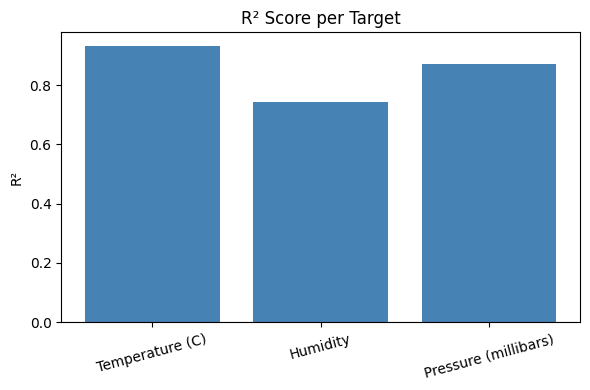

In [14]:
# R2 as a bar chart per target
plt.figure(figsize=(6, 4))
plt.bar(summary_df.index, summary_df["R2"], color="steelblue")
plt.title("R² Score per Target"); plt.ylabel("R²")
plt.axhline(0, color="gray", linewidth=0.8)
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()


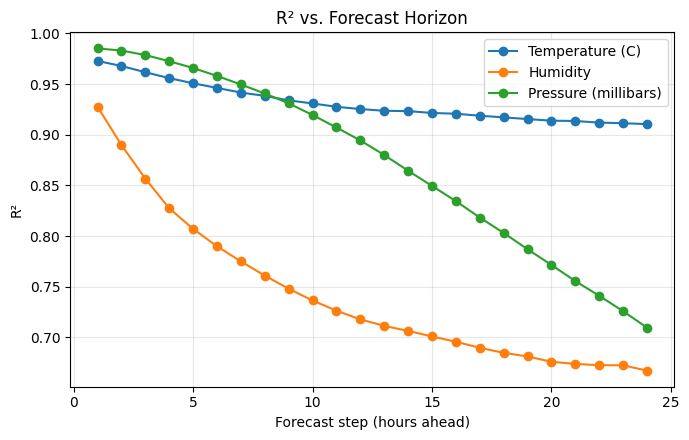

In [15]:
# R2 computed separately AT EACH FORECAST STEP, to see how the model's
# explanatory power degrades the further into the future it predicts.
step_r2 = np.zeros((HORIZON, len(TARGET_COLS)))

for h in range(HORIZON):
    for target_i in range(len(TARGET_COLS)):
        yt = y_true[:, h, target_i]
        yp = y_pred[:, h, target_i]
        step_r2[h, target_i] = r2_score(yt, yp)

plt.figure(figsize=(7, 4.5))
for target_i, col in enumerate(TARGET_COLS):
    plt.plot(range(1, HORIZON + 1), step_r2[:, target_i], marker="o", label=col)

plt.xlabel("Forecast step (hours ahead)"); plt.ylabel("R²")
plt.title("R² vs. Forecast Horizon"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Visualize Sample Multi-Step Forecasts

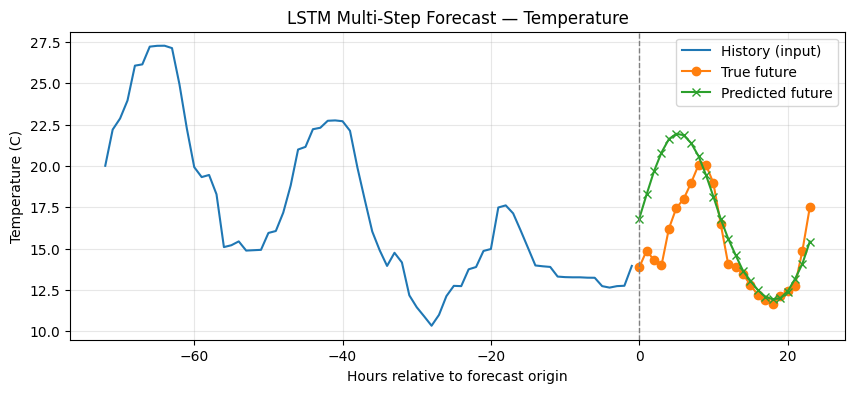

In [16]:
sample_idx = 100  # pick any test sample
target_i = TARGET_COLS.index("Temperature (C)")

history_vals = feature_scaler.inverse_transform(X_test[sample_idx])[:, df.columns.get_loc("Temperature (C)")]
true_future  = y_true[sample_idx, :, target_i]
pred_future  = y_pred[sample_idx, :, target_i]

plt.figure(figsize=(10, 4))
plt.plot(range(-LOOKBACK, 0), history_vals, label="History (input)")
plt.plot(range(0, HORIZON), true_future, label="True future", marker="o")
plt.plot(range(0, HORIZON), pred_future, label="Predicted future", marker="x")
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Hours relative to forecast origin"); plt.ylabel("Temperature (C)")
plt.title(f"{MODEL_TYPE} Multi-Step Forecast — Temperature")
plt.legend(); plt.grid(alpha=0.3)
plt.show()


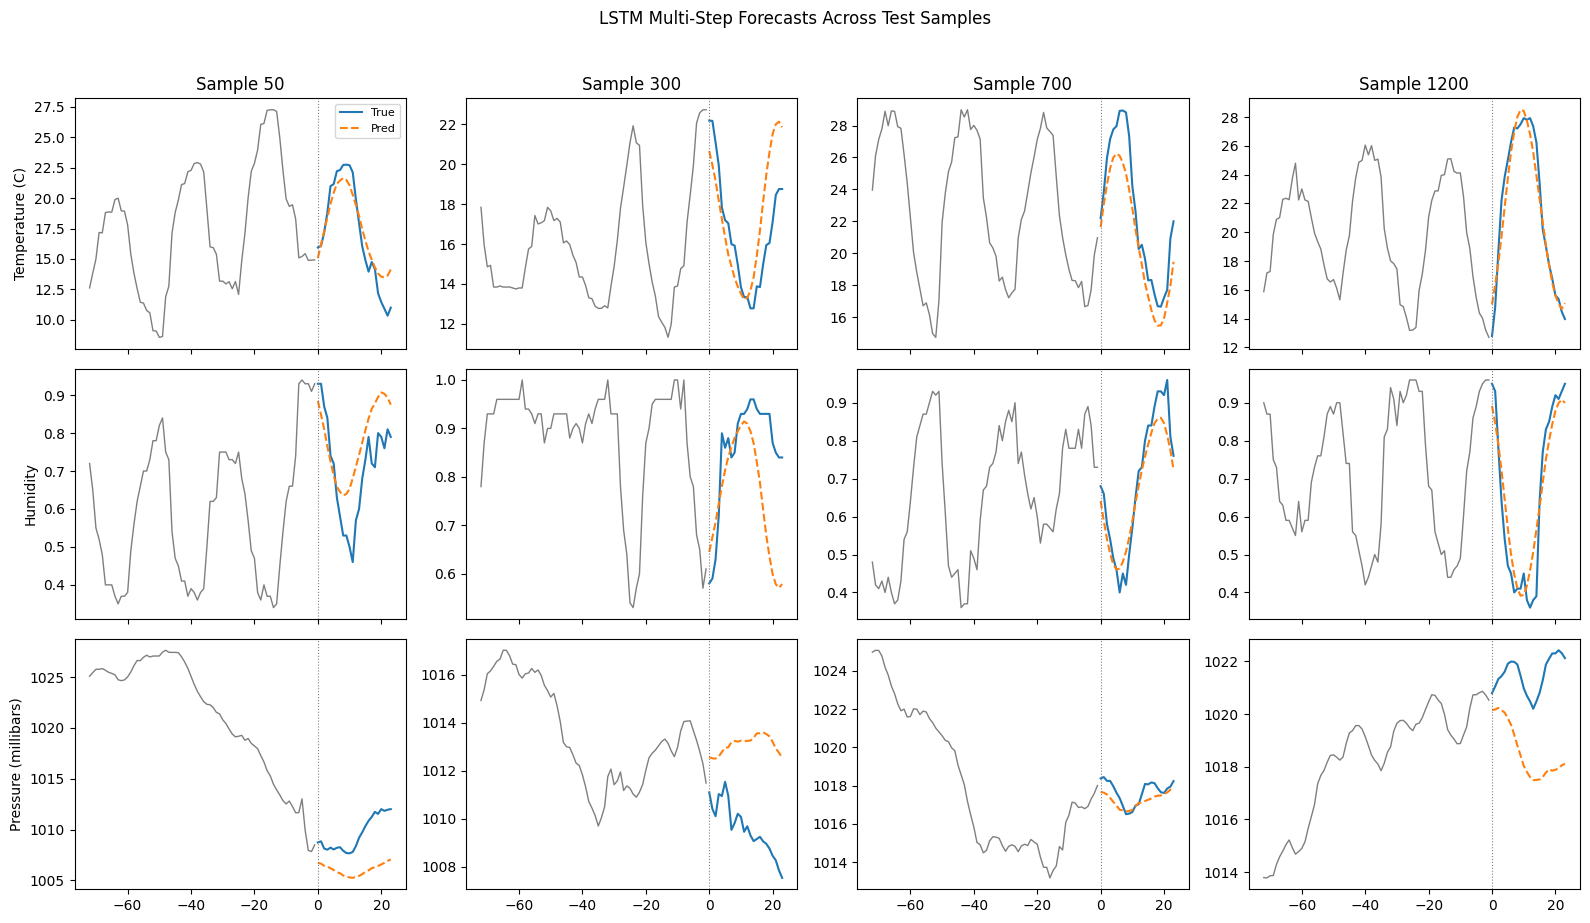

In [17]:
# Grid of sample forecasts, one per target, at a few different points in the test set
sample_indices = [50, 300, 700, 1200]
fig, axes = plt.subplots(len(TARGET_COLS), len(sample_indices), figsize=(4 * len(sample_indices), 3 * len(TARGET_COLS)), sharex=True)

for row, col_name in enumerate(TARGET_COLS):
    t_i = TARGET_COLS.index(col_name)
    for col_pos, s_idx in enumerate(sample_indices):
        ax = axes[row, col_pos]
        hist = feature_scaler.inverse_transform(X_test[s_idx])[:, df.columns.get_loc(col_name)]
        ax.plot(range(-LOOKBACK, 0), hist, color="tab:gray", linewidth=1)
        ax.plot(range(0, HORIZON), y_true[s_idx, :, t_i], label="True", color="tab:blue")
        ax.plot(range(0, HORIZON), y_pred[s_idx, :, t_i], label="Pred", color="tab:orange", linestyle="--")
        ax.axvline(0, color="gray", linestyle=":", linewidth=0.8)
        if row == 0:
            ax.set_title(f"Sample {s_idx}")
        if col_pos == 0:
            ax.set_ylabel(col_name)
        if row == 0 and col_pos == 0:
            ax.legend(fontsize=8)

plt.suptitle(f"{MODEL_TYPE} Multi-Step Forecasts Across Test Samples", y=1.02)
plt.tight_layout(); plt.show()


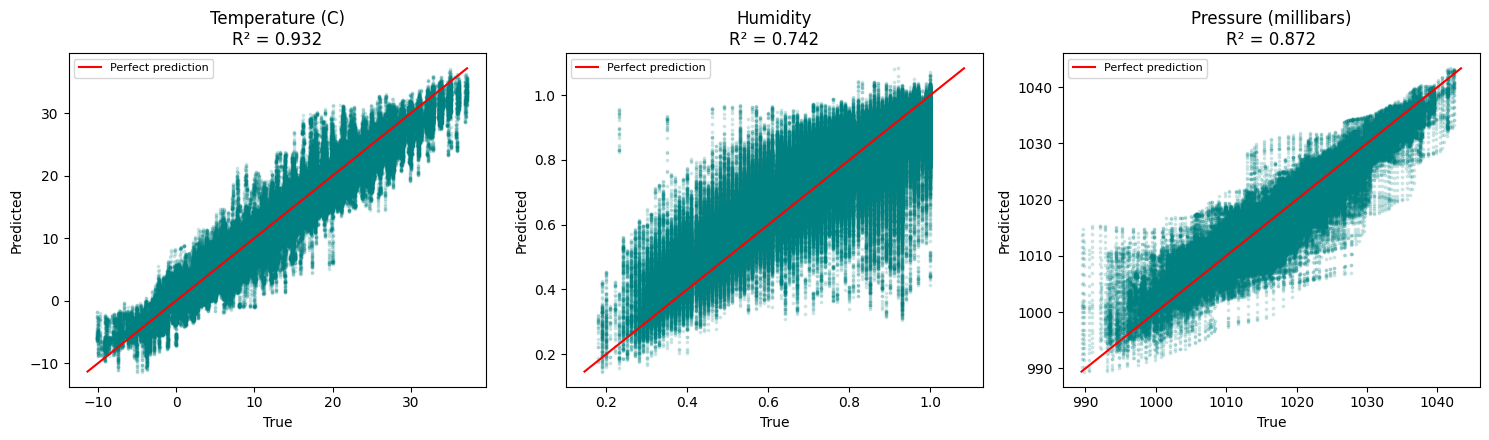

In [18]:
# Scatter: predicted vs. actual, per target (closer to the diagonal = better)
fig, axes = plt.subplots(1, len(TARGET_COLS), figsize=(5 * len(TARGET_COLS), 4.5))

for i, col_name in enumerate(TARGET_COLS):
    yt = y_true[:, :, i].ravel()
    yp = y_pred[:, :, i].ravel()
    axes[i].scatter(yt, yp, s=3, alpha=0.15, color="teal")
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    axes[i].plot(lims, lims, color="red", linewidth=1.5, label="Perfect prediction")
    axes[i].set_xlabel("True"); axes[i].set_ylabel("Predicted")
    axes[i].set_title(f"{col_name}\nR² = {summary_df.loc[col_name, 'R2']:.3f}")
    axes[i].legend(fontsize=8)

plt.tight_layout(); plt.show()


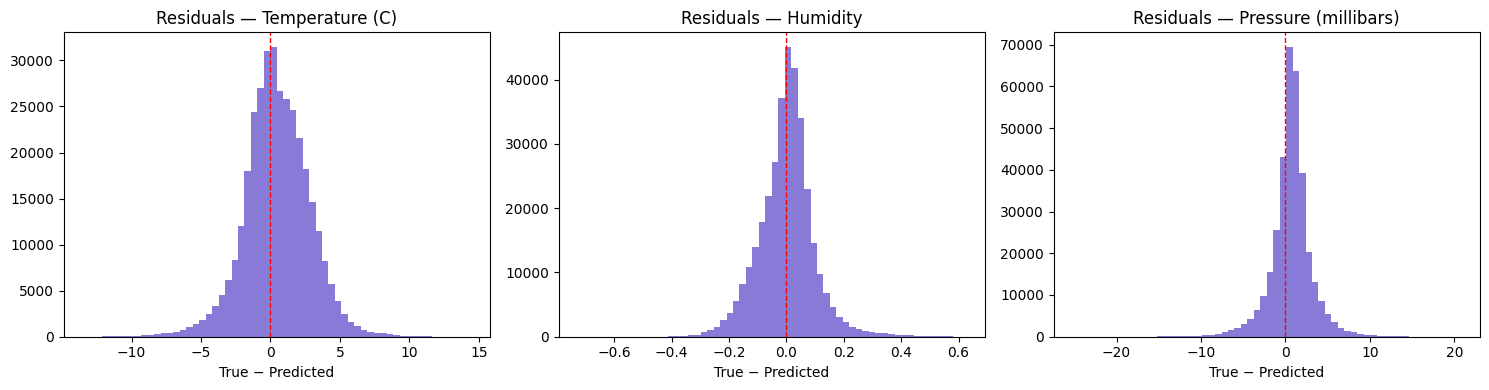

In [19]:
# Residual (error) distribution per target
fig, axes = plt.subplots(1, len(TARGET_COLS), figsize=(5 * len(TARGET_COLS), 4))

for i, col_name in enumerate(TARGET_COLS):
    residuals = (y_true[:, :, i] - y_pred[:, :, i]).ravel()
    axes[i].hist(residuals, bins=60, color="slateblue", alpha=0.8)
    axes[i].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[i].set_title(f"Residuals — {col_name}")
    axes[i].set_xlabel("True − Predicted")

plt.tight_layout(); plt.show()


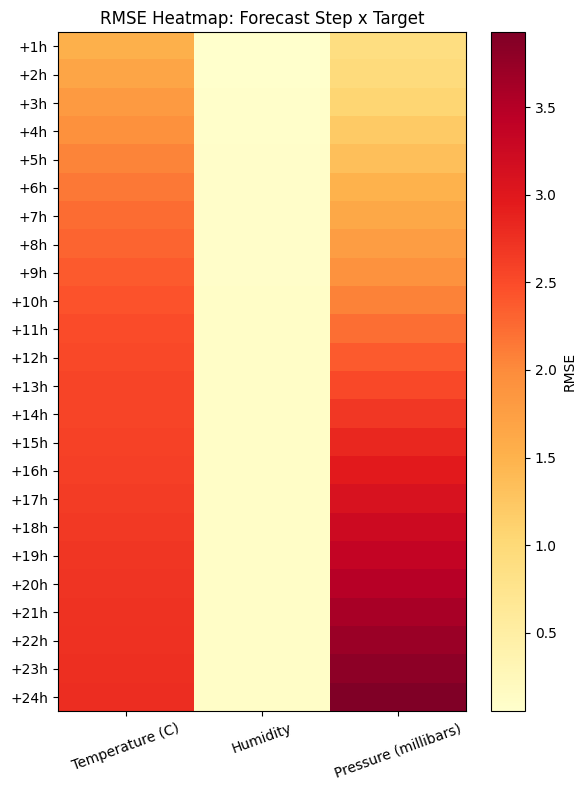

In [20]:
# Heatmap: RMSE for every (forecast step x target) combination
step_target_rmse = np.zeros((HORIZON, len(TARGET_COLS)))
for h in range(HORIZON):
    for t_i in range(len(TARGET_COLS)):
        step_target_rmse[h, t_i] = np.sqrt(mean_squared_error(y_true[:, h, t_i], y_pred[:, h, t_i]))

plt.figure(figsize=(6, 8))
im = plt.imshow(step_target_rmse, aspect="auto", cmap="YlOrRd")
plt.colorbar(im, label="RMSE")
plt.yticks(range(HORIZON), [f"+{h+1}h" for h in range(HORIZON)])
plt.xticks(range(len(TARGET_COLS)), TARGET_COLS, rotation=20)
plt.title("RMSE Heatmap: Forecast Step x Target")
plt.tight_layout(); plt.show()


## 11. Reusable Forecast Function

Forecast the next `HORIZON` hours from any point in the dataset using
only the most recent `LOOKBACK` readings.


In [21]:
def forecast_from(data_scaled: pd.DataFrame, end_timestamp) -> pd.DataFrame:
    """Given scaled feature data and a timestamp, forecast the next HORIZON hours."""
    window = data_scaled.loc[:end_timestamp].iloc[-LOOKBACK:]
    assert len(window) == LOOKBACK, "Not enough history before this timestamp."

    x = window.values[np.newaxis, ...].astype(np.float32)
    pred_scaled = model.predict(x, verbose=0)
    pred = inverse_transform_targets(pred_scaled)[0]

    future_index = pd.date_range(
        start=end_timestamp + pd.Timedelta(hours=1), periods=HORIZON, freq="h"
    )
    return pd.DataFrame(pred, columns=TARGET_COLS, index=future_index)

# Example usage:
example_ts = test_scaled.index[LOOKBACK + 500]
forecast_df = forecast_from(test_scaled, example_ts)
forecast_df.head()


,Temperature (C),Humidity,Pressure (millibars)
2015-06-02 00:00:00+00:00,14.900822,0.897436,1016.563991
2015-06-02 01:00:00+00:00,14.874236,0.904179,1016.532154
2015-06-02 02:00:00+00:00,15.010306,0.898294,1016.476981
2015-06-02 03:00:00+00:00,15.552394,0.877793,1016.361202
2015-06-02 04:00:00+00:00,16.643413,0.838009,1016.461634


## 12. Comparing LSTM vs GRU

Both architectures are trained back-to-back here, using the exact same
data, lookback/horizon, and training setup, so the comparison is
apples-to-apples. GRUs have fewer parameters than LSTMs (no separate cell
state), which often means faster training with comparable accuracy —
this section checks whether that holds true for this dataset.


In [22]:
def train_and_evaluate(rnn_type: str):
    """Build, train, and evaluate one architecture. Returns (model, history, metrics_df)."""
    keras.backend.clear_session()
    tf.random.set_seed(RANDOM_SEED)

    m = build_model(n_features, n_targets, LOOKBACK, HORIZON, rnn_type=rnn_type)

    cbs = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
    ]

    import time
    t0 = time.time()
    hist = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=cbs,
        verbose=0,
    )
    train_time = time.time() - t0

    pred_scaled = m.predict(X_test, verbose=0)
    pred = inverse_transform_targets(pred_scaled)
    true = inverse_transform_targets(y_test)

    rows = {}
    for i, col in enumerate(TARGET_COLS):
        yt, yp = true[:, :, i].ravel(), pred[:, :, i].ravel()
        rows[col] = {
            "R2": r2_score(yt, yp),
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": np.sqrt(mean_squared_error(yt, yp)),
        }
    metrics_df = pd.DataFrame(rows).T
    metrics_df["params"] = m.count_params()
    metrics_df["train_time_sec"] = train_time
    metrics_df["epochs_run"] = len(hist.history["loss"])

    return m, hist, metrics_df

lstm_model, lstm_history, lstm_metrics = train_and_evaluate("LSTM")
gru_model,  gru_history,  gru_metrics  = train_and_evaluate("GRU")

print("LSTM parameters:", lstm_model.count_params(), " | training time (s):", round(lstm_metrics['train_time_sec'].iloc[0], 1))
print("GRU  parameters:", gru_model.count_params(),  " | training time (s):", round(gru_metrics['train_time_sec'].iloc[0], 1))


LSTM parameters: 126280  | training time (s): 159.6
GRU  parameters: 96456  | training time (s): 134.2


In [23]:
# Combine into one comparison table: rows = target, columns = (model, metric)
comparison = pd.concat(
    {"LSTM": lstm_metrics[["R2", "MAE", "RMSE"]], "GRU": gru_metrics[["R2", "MAE", "RMSE"]]},
    axis=1,
)
comparison


LSTM                           GRU            \
                            R2       MAE      RMSE        R2       MAE   
Temperature (C)       0.930391  1.848760  2.441681  0.936457  1.752068   
Humidity              0.733788  0.071114  0.098355  0.748046  0.069364   
Pressure (millibars)  0.874641  1.752201  2.581379  0.879802  1.680545   

                                
                          RMSE  
Temperature (C)       2.332863  
Humidity              0.095685  
Pressure (millibars)  2.527683

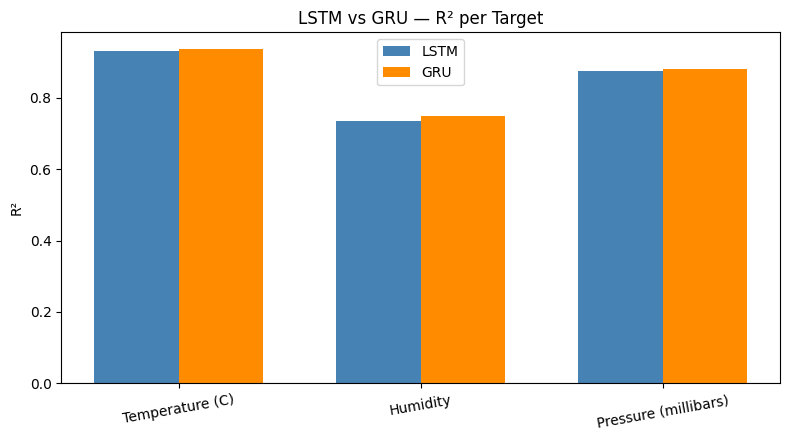

In [24]:
# Side-by-side R2 bar chart per target
x = np.arange(len(TARGET_COLS))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width/2, lstm_metrics["R2"], width, label="LSTM", color="steelblue")
ax.bar(x + width/2, gru_metrics["R2"],  width, label="GRU",  color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(TARGET_COLS, rotation=10)
ax.set_ylabel("R²"); ax.set_title("LSTM vs GRU — R² per Target")
ax.axhline(0, color="gray", linewidth=0.8)
ax.legend()
plt.tight_layout(); plt.show()


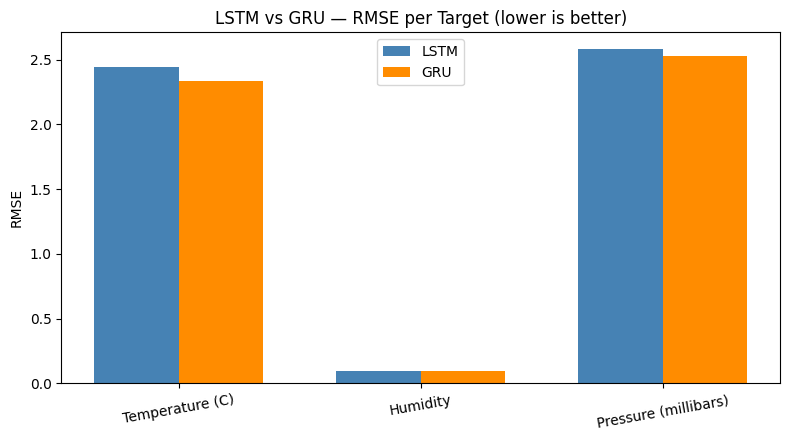

In [25]:
# Side-by-side RMSE bar chart per target (real units, lower is better)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width/2, lstm_metrics["RMSE"], width, label="LSTM", color="steelblue")
ax.bar(x + width/2, gru_metrics["RMSE"],  width, label="GRU",  color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(TARGET_COLS, rotation=10)
ax.set_ylabel("RMSE"); ax.set_title("LSTM vs GRU — RMSE per Target (lower is better)")
ax.legend()
plt.tight_layout(); plt.show()


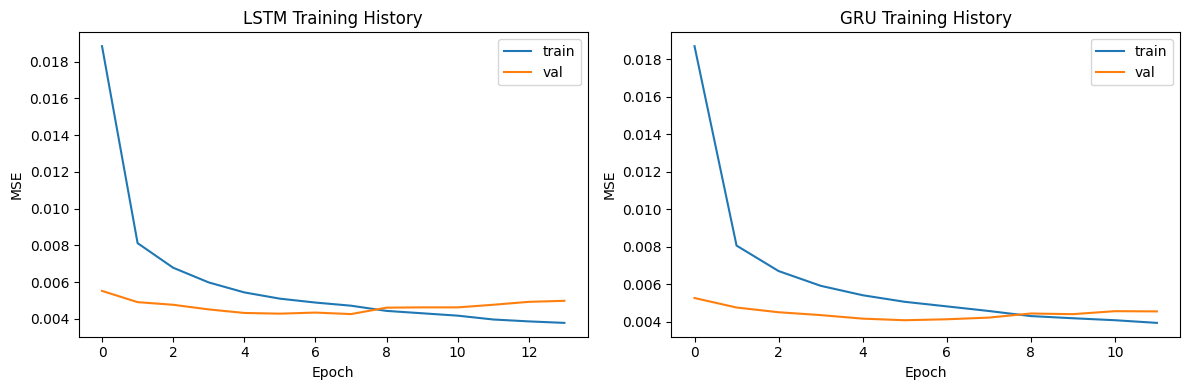

In [26]:
# Training/validation loss curves side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lstm_history.history["loss"], label="train")
axes[0].plot(lstm_history.history["val_loss"], label="val")
axes[0].set_title("LSTM Training History"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE"); axes[0].legend()

axes[1].plot(gru_history.history["loss"], label="train")
axes[1].plot(gru_history.history["val_loss"], label="val")
axes[1].set_title("GRU Training History"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MSE"); axes[1].legend()

plt.tight_layout(); plt.show()


In [27]:
# Efficiency comparison: parameter count and training time
eff = pd.DataFrame({
    "LSTM": [lstm_model.count_params(), lstm_metrics['train_time_sec'].iloc[0], lstm_metrics['epochs_run'].iloc[0]],
    "GRU":  [gru_model.count_params(),  gru_metrics['train_time_sec'].iloc[0],  gru_metrics['epochs_run'].iloc[0]],
}, index=["Parameters", "Train time (s)", "Epochs run"])
eff


,LSTM,GRU
Parameters,126280.000000,96456.0000
Train time (s),159.551171,134.2398
Epochs run,14.000000,12.0000
